# 02 · Sweeps and results

Part 1 built programs that do one thing, once. Every calibration is a loop. Step a knob, measure, step again, and look at the shape of what came back.

Three pieces turn a sequence into an experiment. A variable is the hole in the program where the knob goes. A sweep source says how that variable moves. `average(shots)` repeats the whole thing and hands back a mean.

The other half is the data. `qp.simulate` returns an `xarray.DataArray` whose dimensions carry your variable names and whose axes know how to draw themselves.

Two experiments carry it. Resonator spectroscopy finds the readout resonator. Punchout is the 2D scan that shows the resonator sliding as you push more power at it, and it tells you what power to read out at.

In [1]:
# Run me first. A no-op when qprogram is already installed, an install when it is not
# (a fresh Google Colab runtime, for example).
try:
    import qprogram  # noqa: F401
except ImportError:
    import subprocess
    import sys

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "qprogram[viz]==0.1.0", "scipy"],
        check=True,
    )
    import qprogram  # noqa: F401

from importlib.metadata import version

print("qprogram", version("qprogram"))

qprogram 0.1.0


In [2]:
import numpy as np

import qprogram as qp
from qprogram import MeasurementField as MF
from qprogram.buses import BusSchema
from qprogram.plotting import Quantity, Style
from qprogram.waveforms import Square

schema = BusSchema.transmon()
q = schema.q

print("readout bus:", q[0].readout, "| channel:", q[0].readout.channel,
      "| has ADC:", q[0].readout.acquires)

readout bus: q0/readout | channel: IQ | has ADC: True


## 2.0 The device

Every notebook in this tutorial talks to the same simulated chip and writes its true parameters down in one place. The job of each experiment is to recover them from data. If your fit disagrees with `DEVICE`, either the fit is wrong or you learned something about the analysis.

Part 2 uses three. `q0_fr` is the answer this notebook is looking for. The linewidth `q0_kappa` sets how finely you have to step, because a grid coarser than the dip steps straight over it. The dispersive shift `q0_chi` is the part of the resonator frequency that depends on the qubit, and therefore the part that goes away when you push too hard.

In [3]:
DEVICE = {
    # qubit 0
    "q0_f01": 4.85e9,        # Hz, at the flux sweet spot
    "q0_fr": 7.20e9,         # Hz, readout resonator
    "q0_kappa": 1.5e6,       # Hz, resonator linewidth (FWHM)
    "q0_chi": -1.8e6,        # Hz, dispersive shift
    "q0_a_pi": 0.62,         # drive amplitude of a pi pulse (DAC units)
    "q0_T1": 18_000,         # ns
    "q0_T2star": 9_000,      # ns
    "q0_T2echo": 16_000,     # ns
    "q0_linewidth": 2.0e6,   # Hz, spectroscopy FWHM at low power
    # qubit 1
    "q1_f01": 5.12e9,
    "q1_fr": 7.35e9,
    "q1_a_pi": 0.55,
    "q1_T1": 15_000,
}

print(f"resonator        {DEVICE['q0_fr'] / 1e9:.3f} GHz")
print(f"linewidth kappa  {DEVICE['q0_kappa'] / 1e6:.2f} MHz")
print(f"dispersive shift {DEVICE['q0_chi'] / 1e6:+.2f} MHz")

resonator        7.200 GHz
linewidth kappa  1.50 MHz
dispersive shift -1.80 MHz


## 2.1 Variables

You do not know where the resonator is. A designer drew it and a simulator predicted 7.2 GHz, but the frequency depends on the length of a patterned line and on the kinetic inductance of a sputtered film, and the fab delivers neither to better than a percent. One percent of 7.2 GHz is 72 MHz. The resonance is 1.5 MHz wide. So you write the program once with a hole in it.

`program.variable(id, label=..., units=...)` declares that hole. The id is the only part that matters to the machine, and it becomes the identifier in the `.qp` file and the dimension name in the result. `label` and `units` are for people. Both ride out to the coordinate and label the axes of every figure drawn from it.

Arithmetic on a variable builds an expression tree, and nothing is computed. `freq - 7.2e9` is a `BinaryOp` node holding a variable and a constant, and you can print it, walk it, serialize it, or pass it to any operation that takes a number.

In [4]:
scratch = qp.QProgram(label="expressions", schema=schema)
freq = scratch.variable("freq", label="Readout frequency", units="Hz")
amp = scratch.variable("amp", label="Readout amplitude", units="DAC units")

# Detuning from the resonator, in half-linewidths. An expression, not a number.
detuning = (freq - DEVICE["q0_fr"]) / (DEVICE["q0_kappa"] / 2)

print("the expression:  ", detuning)
print("free variables:  ", sorted(v.id for v in detuning.variables()))
print("value of freq:   ", freq.value)

the expression:   ((Variable('freq') - Constant(7200000000.0)) / Constant(750000.0))
free variables:   ['freq']
value of freq:    UNASSIGNED


### Where the value comes from

A variable holds one value at a time, and it starts out as `UNASSIGNED`. On each iteration the runtime calls `set_value`, every expression built on that variable re-evaluates, and the operations inside the loop see the new number. Nothing is passed as an argument.

Two ways to read a tree. `evaluate()` returns `UNASSIGNED` if anything in it is unbound, so code that inspects a program before it runs never has to guard. `evaluate_or_raise()` insists on a number and raises `UnassignedVariableError` naming what is missing. The interpreter calls that one on every operation.

In [5]:
print("unbound:", detuning.evaluate())   # UNASSIGNED propagates up through the whole tree

freq.set_value(7.2015e9)                 # the loop does exactly this, once per iteration
print("bound:  ", detuning.evaluate())   # 1.5 MHz above resonance is 2.0 half-linewidths
freq.reset()

try:
    detuning.evaluate_or_raise()
except qp.UnassignedVariableError as err:
    print("evaluate_or_raise:", sorted(v.id for v in err.free_variables), "still unbound")

# A waveform parameter is one more slot an expression fits into.
tone = Square(amplitude=amp / 2, duration=8)
amp.set_value(0.8)
print("envelope:", tone.envelope())      # half of 0.8, eight samples of it
amp.reset()

unbound: UNASSIGNED
bound:   2.0
evaluate_or_raise: ['freq'] still unbound
envelope: [0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4]


## 2.2 Sweep sources

`program.sweep(variable, source)` is the only loop in QProgram. There is no `for_loop` and no `while`. What changes between a frequency ramp and a table of calibrated phases is the **source**, a small immutable value object, the sweep analogue of a waveform.

| Source | Kind | Reach for it when |
|---|---|---|
| `qp.Range(start, stop, step)` | linear | you know the spacing |
| `qp.Linspace(start, stop, num)` | linear | you know the point count |
| `qp.Values(seq)` | arbitrary | you have a list: calibrated values, a measured table |
| `qp.Logspace(start, stop, num)` | arbitrary | powers and decay times, anything spanning decades |
| `qp.File(path)` | arbitrary | the list lives in a `.npy` file next to the program |
| `qp.Repeat(src, times)` | arbitrary | the same sweep back to back |
| `qp.Rotate(src, by)` | arbitrary | the same sweep, cyclically shifted |
| `qp.Concat([src, src])` | arbitrary | several sweeps end to end |

**`Range` is `start + step * i`, and it holds `round((stop - start) / step) + 1` points.** It lands on `stop` only when the step divides the span evenly, and otherwise the last point falls short or steps past. Reach for `Linspace` when the last point has to land on `stop`.

In [6]:
print("Range(0, 10, 2)   ->", qp.Range(0, 10, 2).values())    # 6 points, landing on 10
print("Range(0, 10, 3)   ->", qp.Range(0, 10, 3).values())    # 4 points, stopping short at 9
print("Range(0, 1, 0.6)  ->", qp.Range(0, 1, 0.6).values())   # 3 points, overshooting to 1.2
print("Linspace(0, 10, 5)->", qp.Linspace(0, 10, 5).values())
print("Values([...])     ->", qp.Values([7.19e9, 7.20e9, 7.21e9]).values())

span = qp.Range(7.19e9, 7.21e9, 0.2e6)
print("a 20 MHz span at 200 kHz steps:", span.length(), "points")   # 101, not 100

with scratch.sweep(freq).from_range(7.19e9, 7.21e9, 0.2e6):   # no source class named
    pass

print("fluent: ", qp.dumps(scratch).splitlines()[-1].strip())
print("object: for freq in", span)

Range(0, 10, 2)   -> [ 0.  2.  4.  6.  8. 10.]
Range(0, 10, 3)   -> [0. 3. 6. 9.]
Range(0, 1, 0.6)  -> [0.  0.6 1.2]
Linspace(0, 10, 5)-> [ 0.   2.5  5.   7.5 10. ]
Values([...])     -> [7.19e+09 7.20e+09 7.21e+09]
a 20 MHz span at 200 kHz steps: 101 points
fluent:  for freq in Range(start=7190000000.0, stop=7210000000.0, step=200000.0):
object: for freq in Range(start=7190000000.0, stop=7210000000.0, step=200000.0)


### Linear and arbitrary

Every source declares a `KIND`, either `"linear"` or `"arbitrary"`, and a capability `TOKEN`.

`"linear"` is a promise about the values. Point $i$ is exactly `start + step * i`, so a sequencer can run the loop out of a hardware register, incrementing a frequency word per iteration, with nothing uploaded and no control computer in the loop.

`"arbitrary"` means the values are a list, and a list has to reach the instrument somehow. The platform either uploads it as a table, which costs sequencer memory, or steps it from the host, one round trip per point. Both are slower. Part 5 reads a real capability descriptor and prints which domain each loop ended up in.

`Values` is arbitrary **even when the numbers you pass are evenly spaced**, because a list of floats proves nothing about its own regularity. If your sweep really is a ramp, say `Range` or `Linspace`.

The tokens are how a platform declines. A rack whose sequencer cannot do log sweeps refuses `sweep.logspace`, and refuses it inside a combinator too, since combinators union their children's tokens.

In [7]:
sources = [
    qp.Range(7.19e9, 7.21e9, 0.2e6),
    qp.Linspace(0.0, 1.0, 21),
    qp.Values([0.0, 0.05, 0.10, 0.15]),   # an even ramp, and still arbitrary
    qp.Logspace(0.01, 1.0, 21),
]
for src in sources:
    print(f"{src!r:60} {src.KIND:10} {src.length():4d} points  {sorted(src.tokens())}")

Range(start=7190000000.0, stop=7210000000.0, step=200000.0)  linear      101 points  ['sweep.linear', 'sweep.range']
Linspace(start=0.0, stop=1.0, num=21)                        linear       21 points  ['sweep.linear', 'sweep.linspace']
Values(points=array([0.  , 0.05, 0.1 , 0.15]))               arbitrary     4 points  ['sweep.arbitrary', 'sweep.values']
Logspace(start=0.01, stop=1.0, num=21)                       arbitrary    21 points  ['sweep.arbitrary', 'sweep.logspace']


### Combinators

Three sources take another source and rearrange it. `Repeat` runs a scan twice back to back so you can overlay the halves and see whether the chip moved under you, the cheapest drift check there is. `Rotate` shifts a phase list so the reference point lands elsewhere without rewriting the list. `Concat` glues a coarse survey to a fine scan, so one program covers a wide band at low resolution and the interesting few megahertz at high resolution.

All three are arbitrary, and all three report their child's tokens alongside their own.

In [8]:
base = qp.Values([0.0, 0.5, 1.0])
print("Repeat(base, 2) ", qp.Repeat(base, 2).values())
print("Rotate(base, 1) ", qp.Rotate(base, 1).values())
print("Concat([...])   ", qp.Concat([base, qp.Linspace(2.0, 3.0, 3)]).values())

# The tokens travel upward, so a platform without log sweeps also refuses this:
print("Rotate(Logspace(...)) needs:", sorted(qp.Rotate(qp.Logspace(0.01, 1.0, 4), 1).tokens()))

Repeat(base, 2)  [0.  0.5 1.  0.  0.5 1. ]
Rotate(base, 1)  [0.5 1.  0. ]
Concat([...])    [0.  0.5 1.  2.  2.5 3. ]
Rotate(Logspace(...)) needs: ['sweep.arbitrary', 'sweep.logspace', 'sweep.rotate']


There is a second spelling for the same loop. `program.sweep(freq).from_range(...)` and its siblings `.from_linspace(...)`, `.from_logspace(...)`, `.from_values(...)` and `.from_file(...)` build the same `Sweep` node without naming a source class. A bare list in the source position works too, and means `Values`.

This part passes source objects throughout, because `KIND` and the capability tokens live on the class, and because `qp.Concat([qp.Rotate(base, by=i) for i in range(4)])` has no `from_*` equivalent. Recognize both spellings, since the library's own landing page opens with the fluent one.

## 2.3 `average(shots)` adds no dimension

A single measurement of a superconducting qubit is noisy in two unrelated ways.

The first is the amplifier chain. What comes back from the fridge is a few tens of microwave photons at 7 GHz, and every stage between the chip and the ADC adds noise to it. Even a quantum-limited parametric amplifier adds half a photon of vacuum noise. That noise lands on the `iq` point.

The second is the qubit. A superposition is not a dim signal, it is a coin. Measure a state that is half excited and you get a 1 or a 0, never a 0.5. That spread is the projection itself rather than anything the electronics did, and it lands on the `state` field.

Both shrink as $1/\sqrt{N}$, so one knob fixes both. They differ in where the floor is. The first improves when you buy a better amplifier, and the second cannot be improved at all.

Repetition beats both down, and `with program.average(shots=N)` is how you ask for it. It is the one loop that does **not** show up as a dimension in the result. `iq` and `raw` come back as means over the shots, and `state` comes back as the excited-state population. When you do want the individual shots there is a trick for it in Part 4.

The cell below runs one flat, noisy scan at four shot counts.

In [9]:
def noise_scan(shots):
    """Measure a constant signal 64 times, averaged `shots` deep. Returns the iq array."""
    p = qp.QProgram(label=f"flat_{shots}", schema=schema)
    idx = p.variable("idx")
    with p.average(shots=shots):
        with p.sweep(idx, qp.Range(0, 63, 1)):
            m = p.measure(q[0].readout, "readout", "weights")
    flat = qp.MockMeasurementModel(response=lambda bus, env: 1 + 0j, noise=0.5, seed=5)
    return qp.simulate(p, model=flat).get(m)


for shots in (1, 4, 64, 256):
    da = noise_scan(shots)
    spread = da.sel(IQ="I").values.std()
    print(f"shots={shots:4d}  dims={da.dims}  shape={da.shape}  std(I)={spread:.4f}")

shots=   1  dims=('idx', 'IQ')  shape=(64, 2)  std(I)=0.5473
shots=   4  dims=('idx', 'IQ')  shape=(64, 2)  std(I)=0.2596
shots=  64  dims=('idx', 'IQ')  shape=(64, 2)  std(I)=0.0664


shots= 256  dims=('idx', 'IQ')  shape=(64, 2)  std(I)=0.0305


The shape never changes. The spread falls as $1/\sqrt{N}$, so halving the noise costs four times the measurement time. Doubling your shots buys you 1.4x. Fixing the thing that made the signal small, a badly placed readout frequency or a lossy cable, routinely buys ten times that. Reach for shots last.

Averaging does something different to the `state` field. One shot is classified 0 or 1, so one shot gives you a bit. Average 500 and the same array position holds a population. Nothing about the array shape says which of the two you are holding, because the shot count decides and the shot count is not in the result.

In [10]:
def population_scan(shots):
    """Five repeats of a measurement on a qubit that is excited 30% of the time."""
    p = qp.QProgram(label=f"pop_{shots}", schema=schema)
    rep = p.variable("rep")
    with p.average(shots=shots):
        with p.sweep(rep, qp.Range(0, 4, 1)):
            m = p.measure(q[0].readout, "readout", "weights", fields=(MF.IQ, MF.STATE))
    biased = qp.MockMeasurementModel(
        response=lambda bus, env: 0j, p_excited=lambda bus, env: 0.3, noise=0.0, seed=9
    )
    return qp.simulate(p, model=biased).get(m, field=MF.STATE)


print("shots=1   ->", population_scan(1).values)      # one classified shot per point
print("shots=500 ->", population_scan(500).values)    # the same shape, now a population near 0.3

shots=1   -> [0. 1. 0. 0. 0.]
shots=500 -> [0.27  0.318 0.308 0.258 0.304]


## 2.4 The measurement model

`qp.simulate` runs the program on `ReferencePlatform`, a pure-Python interpreter that ships inside QProgram. It walks the AST, drives the loops, binds the variables, and asks a **measurement model** for one sample per shot per `measure`. The model is the only source of numbers.

`MockMeasurementModel(response=..., p_excited=..., noise=..., raw_samples=..., seed=...)` covers most cases. Your `response(bus, env)` returns one noiseless complex IQ point. `bus` is the bus being measured, so one model can answer differently for two resonators. `env` is a dict of the currently bound loop variables, keyed by variable id, plus any platform parameters keyed as `"bus.parameter"`.

### The simulator is not physics

The pulses you play, the waits, the syncs and the gains you set are all recorded in the AST, validated against the platform, and then ignored by the interpreter. There is no timing model and no waveform model. When you sweep an amplitude and watch a dip move, it moved because your `response` function read `env["ro_amp"]` and did the arithmetic itself.

It is a choice about what is under test. The program has to say the right thing to a machine, and the analysis has to get the right number out of noisy data. Both are identical here and on hardware. The qubit is the only stand-in.

Every `measure` here passes the string aliases `"readout"` and `"weights"` and never binds them to waveforms, and the run works anyway, because the interpreter never looks at a pulse. A real platform does look, so `program.with_waveforms(library)` has to come first. Part 3 does that binding for real.

### `set_parameter`

`set_frequency` and `set_gain` write registers a sequencer owns. `set_parameter(bus, name, value)` writes something the platform holds as configuration instead, an attenuator setting or a local oscillator, and platforms expose it host-side only for that reason. The name is a free string that nothing validates, so a typo becomes a parameter the platform has never heard of rather than an error at the call site. Its value reaches the measurement model under the key `"bus.parameter"`, so `env` below carries `q0/readout.attenuation` alongside the loop variables. `get_parameter` is the read direction, handing back a variable the runtime fills in.

The write sits above both loops on purpose, because one attenuator setting covers the whole scan. Part 5 has the tools that tell you when a write inside a loop has dragged the loop off the sequencer with it.

In [11]:
seen = []


def peek(bus, env):
    """A response function that records what it was asked, then returns a flat signal."""
    seen.append((str(bus), dict(env)))
    return 1 + 0j


env_probe = qp.QProgram(label="env_probe", schema=schema)
ro_freq = env_probe.variable("ro_freq", units="Hz")
ro_amp = env_probe.variable("ro_amp", units="DAC units")
env_probe.set_parameter(q[0].readout, "attenuation", 30.0)  # above the loops, deliberately
with env_probe.average(shots=2):
    with env_probe.sweep(ro_amp, qp.Values([0.1, 0.4])):
        with env_probe.sweep(ro_freq, qp.Linspace(7.19e9, 7.21e9, 3)):
            env_probe.measure(q[0].readout, "readout", "weights")

# qp.simulate() builds one of these per call and forwards model=, schema= and parameters= into it.
# The platform is spelled out here because section 6.4 works with the object directly.
platform = qp.ReferencePlatform(model=qp.MockMeasurementModel(response=peek))
platform.execute(env_probe)

print("samples requested:", len(seen), "= 2 shots x 2 amplitudes x 3 frequencies")
print("bus:", seen[0][0])
print("env:", seen[0][1])

samples requested: 12 = 2 shots x 2 amplitudes x 3 frequencies
bus: q0/readout
env: {'ro_freq': 7190000000.0, 'ro_amp': 0.1, 'q0/readout.attenuation': 30.0}


## 2.5 Resonator spectroscopy

Resonator spectroscopy is the first measurement on a new chip. Send a tone down the feedline, step its frequency across the band where the readout resonator should be, and record what comes back.

The geometry explains the shape of the curve. The resonator hangs off the side of a feedline that runs past it to the output port, hence the two names it goes by, hanger and notch. Off resonance the resonator is invisible and the tone reaches the output untouched, so $|S_{21}| = 1$. On resonance it absorbs power out of the feedline and dumps it, so less arrives at the output and the trace dips.

$$ S_{21}(f) = 1 - \frac{0.9}{1 + i\,\delta}, \qquad \delta = \frac{f - f_r}{\kappa / 2} $$

The centre of the dip is the frequency, the width is the linewidth $\kappa$, and the depth is a loss budget.

### The loss budget

For a notch resonance the depth is $Q_L/Q_c$, the fraction of the total loss that goes out through the coupler rather than into the material. A dip 90 percent deep means nine tenths of the energy leaves the way you want it to. Run the numbers: $Q_L = f_r/\kappa = 4800$, so $Q_c = Q_L/0.9 = 5300$ and $1/Q_i = 1/Q_L - 1/Q_c$ gives $Q_i = 48000$. Overcoupled by a factor of ten, and for readout that is the right direction, because a photon lost to the substrate carries its information nowhere.

A shallow dip on a real chip is bad news rather than a measurement problem. It means $Q_i$ has collapsed, and the usual culprits are a warm fridge, a stray photon population, or a two-level defect sitting at the resonator's frequency.

The $S_{21}$ model above carries no amplitude, so the dip sits on the bare resonator frequency. How hard the feedline is driven moves that answer, and section 2.7 puts the power axis back. Everything else is the program:

- one variable, `ro_freq`, swept with `Range` across a 20 MHz window,
- `set_frequency` on the readout bus, so the tone follows the variable,
- `measure`, returning the handle you pull data out with,
- 200 shots per point.

In [12]:
def s21(bus, env):
    """Transmission past one resonator: a Lorentzian notch, 90% deep on resonance."""
    detuning = (env["ro_freq"] - DEVICE["q0_fr"]) / (DEVICE["q0_kappa"] / 2)
    return 1.0 - 0.9 / (1.0 + 1j * detuning)


spec = qp.QProgram(
    label="resonator_spectroscopy", description="find the q0 readout resonator", schema=schema
)
ro_freq = spec.variable("ro_freq", label="Readout frequency", units="Hz")

with spec.average(shots=200):
    with spec.sweep(ro_freq, qp.Range(7.19e9, 7.21e9, 0.2e6)):
        spec.set_frequency(q[0].readout, ro_freq)
        m_spec = spec.measure(q[0].readout, "readout", "weights")

print(qp.dumps(spec))

#!QProgram 1.0

metadata:
  label: "resonator_spectroscopy"
  description: "find the q0 readout resonator"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

body:
  var ro_freq label="Readout frequency" units="Hz"

  average 200:
    for ro_freq in Range(start=7190000000.0, stop=7210000000.0, step=200000.0):
      set_frequency q[0].readout ro_freq
      measure q[0].readout "readout" "weights" name="q0/readout/m0"



In [13]:
result = qp.simulate(spec, model=qp.MockMeasurementModel(response=s21, noise=0.02, seed=7))

iq = result.get(m_spec)
freqs = iq.coords["ro_freq"].values
s21_data = iq.sel(IQ="I").values + 1j * iq.sel(IQ="Q").values

print("dims:", iq.dims, "shape:", iq.shape)
print("101 frequencies by 2 quadratures. The 200 shots are gone: average() collapsed them.")
print("first three points:", np.round(s21_data[:3], 3))

dims: ('ro_freq', 'IQ') shape: (101, 2)
101 frequencies by 2 quadratures. The 200 shots are gone: average() collapsed them.
first three points: [0.995-0.07j  0.995-0.068j 0.994-0.071j]


### Reading the numbers off the curve

`argmin` is enough for the centre, and it can never beat your step size. A 200 kHz grid gives you the resonator to 200 kHz. Part 3 fits a real curve and does better.

The width needs one step of care. The dip in $|S_{21}|$ is not a Lorentzian. $S_{21}$ is one minus a complex Lorentzian, and taking the magnitude mixes the real and imaginary parts, so the half-depth width you see is not $\kappa$. Subtract the off-resonance baseline and square what is left. $|S_{21} - 1|^2$ is a plain Lorentzian in power whose full width at half maximum is $\kappa$ exactly. `np.interp` reads the crossings between grid points, which is how the number below lands within 10 kHz.

In [14]:
f_dip = freqs[np.abs(s21_data).argmin()]

baseline = np.mean(np.concatenate([s21_data[:5], s21_data[-5:]]))   # flat away from resonance
lorentzian = np.abs(baseline - s21_data) ** 2
lorentzian = lorentzian / lorentzian.max()

peak = lorentzian.argmax()
left = np.interp(0.5, lorentzian[: peak + 1], freqs[: peak + 1])           # rising edge
right = np.interp(0.5, lorentzian[peak:][::-1], freqs[peak:][::-1])        # falling edge, reversed

print(f"f_r    measured {f_dip / 1e9:.6f} GHz    true {DEVICE['q0_fr'] / 1e9:.6f} GHz")
print(f"kappa  measured {(right - left) / 1e6:.3f} MHz     true {DEVICE['q0_kappa'] / 1e6:.3f} MHz")
print(f"sweep step {(freqs[1] - freqs[0]) / 1e3:.0f} kHz, so f_r is quantised to that")

f_r    measured 7.200000 GHz    true 7.200000 GHz
kappa  measured 1.509 MHz     true 1.500 MHz
sweep step 200 kHz, so f_r is quantised to that


### Drawing the result

`result.plot(handle)` reads the array the way `result.get(handle)` reads it and lets the shape choose the figure. One swept dimension besides `IQ` makes a line, and `channels="magnitude"` takes the hypotenuse of the two quadratures. Nothing in the call names the x axis, because the variable was declared with a label and a unit and both rode out to the coordinate.

A frequency axis wants gigahertz, so `coords=` restates the unit for the figure alone. The restatement is a pair and the library insists on both halves. `units="GHz"` alone would relabel numbers it never moved, and `transform=lambda v: v / 1e9` alone would leave an axis reading hertz over values near 7.2.

The drawn numbers moved, so anything you hand the returned `Axes` afterwards is in the figure's units too, and both reference lines below are divided by `1e9` while `f_dip` stays in hertz. `Style(markers=True)` puts a dot at each measured point, and the line between the dots is the renderer joining them up.

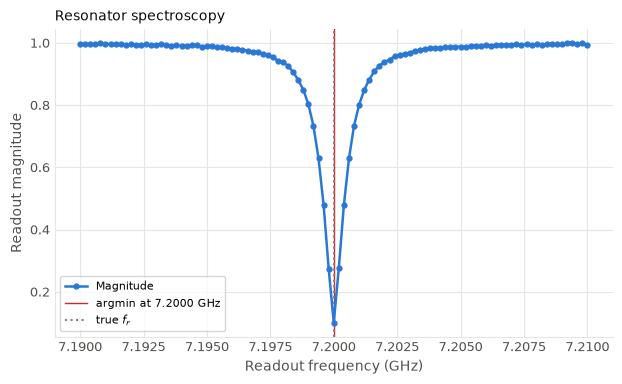

In [15]:
ax = result.plot(
    m_spec,
    channels="magnitude",
    coords={"ro_freq": Quantity(units="GHz", transform=lambda v: v / 1e9)},
    value=Quantity("Readout magnitude"),
    style=Style(markers=True),
    title="Resonator spectroscopy",
)
ax.axvline(f_dip / 1e9, color="tab:red", lw=1, label=f"argmin at {f_dip / 1e9:.4f} GHz")
ax.axvline(DEVICE["q0_fr"] / 1e9, color="grey", ls=":", label="true $f_r$")
ax.legend(fontsize=8)

Draw the same measurement with `channels="phase"` and you get the other half of the story. Magnitude shows the dip and you look at it first, but it flattens out when the dip is shallow, and an over-coupled resonator often gives a shallow dip. Phase turns by about a radian either side of the resonance and stays readable there.

The size of the turn is set by the coupling. In the complex plane the trace draws a circle of diameter 0.9 that passes through $1$ off resonance and through $0.1$ on it, so its centre sits at $0.55$ and the largest phase excursion is $\arcsin(0.45/0.55) = 55$ degrees. A phase that swings the full $\pi$ instead means the resonator is critically coupled and half your photons are going into the substrate.

total phase swing 109 degrees, against the 110 the loss budget predicts


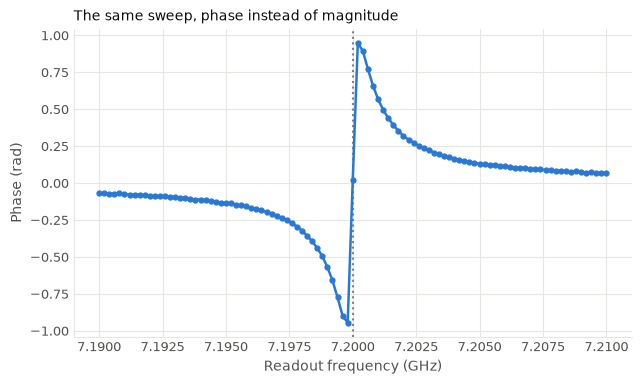

In [16]:
ax_phase = result.plot(
    m_spec,
    channels="phase",
    coords={"ro_freq": Quantity(units="GHz", transform=lambda v: v / 1e9)},
    value=Quantity("Phase", "rad"),
    style=Style(markers=True),
    title="The same sweep, phase instead of magnitude",
)
ax_phase.axvline(DEVICE["q0_fr"] / 1e9, color="grey", ls=":")

phase = np.unwrap(np.angle(s21_data))
swing = np.degrees(phase.max() - phase.min())
print(f"total phase swing {swing:.0f} degrees, against the 110 the loss budget predicts")

## 2.6 Results are xarray

`qp.simulate` returns a `QProgramResult`, one record per `measure` call, keyed by the handle. `result.get(handle)` hands you an `xarray.DataArray` whose dimensions are the enclosing sweeps, outermost first, named after your **variable ids**, with the swept values as coordinates. Integrated measurements carry one extra `IQ` axis of length two.

The ids have to be identifiers for that reason. They are the dimension names you type in `.sel()` and the identifiers in the `.qp` file. Pick them like column names.

The label and the units ride out alongside the id and land on the coordinate as `long_name` and `units`, the words the figure above put on its axis. Declaring both when you declare the variable is the whole of plot labeling, done once.

### Three ways to name a record

`get` accepts three spellings of the same question. A handle is the one to prefer, because it says what it means and survives a reordering of the program. A plain name string selects the same record, and you reach for that form when the handle objects are gone, after loading a program back from a `.qp` file in a session that never built it. An integer is positional sugar for declaration order. `bus=` narrows the candidates first, so `get(0, bus=q[1].readout)` means the first measurement on that bus. `plot` takes all three spellings too.

`result.get(handle)` defaults to `field=MF.IQ`. Ask for a field the measurement never requested and you get a `KeyError`, including the default, so a state-only measurement needs `field=MF.STATE` spelled out.

In [17]:
print(iq.isel(ro_freq=slice(0, 4)))   # the first four rows, so the repr fits on screen

print("\nwhat the variable left on the coordinate:", iq.coords["ro_freq"].attrs)

# Label-based selection is the point of xarray: no index arithmetic, no guessing the axis order.
on_resonance = iq.sel(IQ="I").sel(ro_freq=DEVICE["q0_fr"], method="nearest")
print("I at the resonator:", round(float(on_resonance), 4))

try:
    result.get(m_spec, field=MF.STATE)   # this measurement asked for iq and nothing else
except KeyError as err:
    print("asking for a field that was never requested:", err)

<xarray.DataArray (ro_freq: 4, IQ: 2)> Size: 64B
array([[ 0.99538331, -0.06951379],
       [ 0.99463926, -0.06772279],
       [ 0.99424955, -0.0712499 ],
       [ 0.99247738, -0.07039821]])
Coordinates:
  * ro_freq  (ro_freq) float64 32B 7.19e+09 7.19e+09 7.19e+09 7.191e+09
  * IQ       (IQ) <U1 8B 'I' 'Q'

what the variable left on the coordinate: {'long_name': 'Readout frequency', 'units': 'Hz'}
I at the resonator: 0.1005
asking for a field that was never requested: "Measurement 'q0/readout/m0' has no field 'state'; available: iq"


## 2.7 Punchout

You have the resonator frequency at one particular readout power, and that is not enough to set up readout, because the frequency you measured depends on the power you measured it with.

Dispersive readout works because the qubit and the resonator are coupled but far apart in frequency, so they cannot swap energy and can only shift each other. The approximation behind that has a validity limit, and the limit is a photon number.

$$ n_{\text{crit}} = \frac{\Delta^2}{4g^2} $$

Inverting the $\chi$ of the opening, $\chi = (g^2/\Delta)(\alpha/(\Delta + \alpha))$ with $\alpha \approx -300$ MHz, backs out $g \approx 190$ MHz for this chip. The limit is about 37 photons. Below it the resonator sits at $f_r + \chi$, pulled by the qubit. Drive the cavity harder and the pull washes out, and the resonator lands on its bare frequency $f_r$. The crossover is called punchout, and it is abrupt enough to be obvious in a 2D map.

### Choosing a readout power

The map is how you choose a readout power, and the choice squeezes from both sides. More photons means more signal, and signal-to-noise per shot grows with the square root of the photon number. But the information lives in the $2\chi$ pull, and the pull is the thing punchout destroys. So you park a few decibels below the crossover, with enough photons to separate the two states in one shot and few enough that there are still two states to separate. On this chip the pull has halved by 0.35 in DAC units, which puts the 0.2 that Part 1 wrote into `readout_pulse` about 5 dB under the crossover. Every readout from here to the capstone plays at that amplitude, and this map is the scan that justifies it.

The program is the one-dimensional scan with a second sweep wrapped around it. Two nested `with` statements, two variables, and the outer one becomes the outer dimension. Shots times points is the number to keep an eye on, in the simulator and on real hardware alike.

In [18]:
def s21_power(bus, env):
    """The resonator sits at f_r + chi at low power and slides to bare f_r as it saturates."""
    saturation = 1.0 / (1.0 + (env["ro_amp"] / 0.35) ** 2)
    f_eff = DEVICE["q0_fr"] + DEVICE["q0_chi"] * saturation
    detuning = (env["ro_freq"] - f_eff) / (DEVICE["q0_kappa"] / 2)
    return 1.0 - 0.9 / (1.0 + 1j * detuning)


punchout = qp.QProgram(label="punchout", schema=schema)
pun_amp = punchout.variable("ro_amp", label="Readout amplitude", units="DAC units")
pun_freq = punchout.variable("ro_freq", label="Readout frequency", units="Hz")

with punchout.average(shots=50):
    with punchout.sweep(pun_amp, qp.Linspace(0.02, 1.0, 25)):
        with punchout.sweep(pun_freq, qp.Linspace(7.1955e9, 7.2025e9, 41)):
            punchout.set_gain(q[0].readout, pun_amp)
            punchout.set_frequency(q[0].readout, pun_freq)
            m_pun = punchout.measure(q[0].readout, "readout", "weights")

shot_loop = punchout.body.elements[0]          # Average
outer_sweep = shot_loop.elements[0]            # Sweep over ro_amp
inner_sweep = outer_sweep.elements[0]          # Sweep over ro_freq
print("points:", 25 * 41, "at 50 shots =", 25 * 41 * 50, "samples")
print(f"nesting: {type(shot_loop).__name__}({shot_loop.shots}) -> "
      f"{type(outer_sweep).__name__}({outer_sweep.variable.id}) -> "
      f"{type(inner_sweep).__name__}({inner_sweep.variable.id})")

points: 1025 at 50 shots = 51250 samples
nesting: Average(50) -> Sweep(ro_amp) -> Sweep(ro_freq)


Two sweeps make two plot dimensions, so the same `result.plot` call draws a heatmap here, with the magnitude on the colour bar because a surface has one number per cell to colour. The inner sweep runs along x and the outer up y, matching the loop nesting, so frequency comes out left to right and power upward without either being asked for. `x=` and `y=` override that, and naming one settles the other.

Both variables were declared with a label and a unit, so the two axes and the colour bar name themselves. The white lines are at $f_r + \chi$ and at bare $f_r$.

dims: ('ro_amp', 'ro_freq', 'IQ') shape: (25, 41, 2) (outermost sweep first)


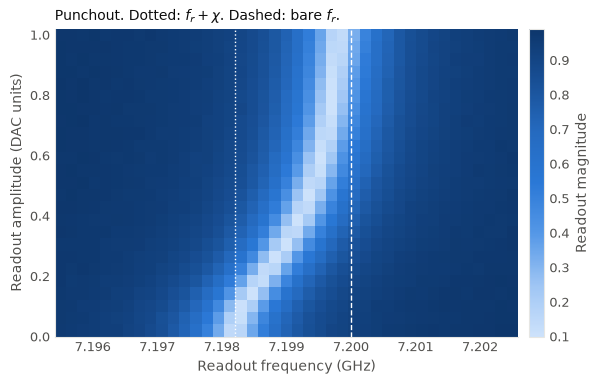

In [19]:
punch_result = qp.simulate(
    punchout, model=qp.MockMeasurementModel(response=s21_power, noise=0.02, seed=11)
)
punch_iq = punch_result.get(m_pun)
print("dims:", punch_iq.dims, "shape:", punch_iq.shape, "(outermost sweep first)")

ax_pun = punch_result.plot(
    m_pun,
    coords={"ro_freq": Quantity(units="GHz", transform=lambda v: v / 1e9)},
    value=Quantity("Readout magnitude"),
    title=r"Punchout. Dotted: $f_r + \chi$. Dashed: bare $f_r$.",
)
ax_pun.axvline((DEVICE["q0_fr"] + DEVICE["q0_chi"]) / 1e9, color="w", ls=":", lw=1)
ax_pun.axvline(DEVICE["q0_fr"] / 1e9, color="w", ls="--", lw=1)

In [20]:
punch_mag = np.abs(punch_iq.sel(IQ="I") + 1j * punch_iq.sel(IQ="Q")).values
amps = punch_iq.coords["ro_amp"].values
scan_freqs = punch_iq.coords["ro_freq"].values
dip_per_amp = scan_freqs[punch_mag.argmin(axis=1)]

for k in (0, 12, 24):
    print(f"amplitude {amps[k]:.2f} V  ->  dip at {dip_per_amp[k] / 1e9:.6f} GHz")
print(f"low-power target   f_r + chi = {(DEVICE['q0_fr'] + DEVICE['q0_chi']) / 1e9:.6f} GHz")
print(f"high-power target  bare f_r  = {DEVICE['q0_fr'] / 1e9:.6f} GHz")
print(f"frequency step {(scan_freqs[1] - scan_freqs[0]) / 1e3:.0f} kHz,"
      " which is all the accuracy an argmin can have")

amplitude 0.02 V  ->  dip at 7.198125 GHz
amplitude 0.51 V  ->  dip at 7.199350 GHz
amplitude 1.00 V  ->  dip at 7.199875 GHz
low-power target   f_r + chi = 7.198200 GHz
high-power target  bare f_r  = 7.200000 GHz
frequency step 175 kHz, which is all the accuracy an argmin can have


### The log power axis

Readout power spans decades, and a linear amplitude axis spends most of its points at the top end where nothing is moving any more. The pull in `s21_power` has already halved at 0.35 V. A `Logspace` sweep puts most of its points below that, where the crossover is, and takes fewer measurements doing it.

That costs something at the other end. `Logspace` is `arbitrary`, so no sequencer register can produce it and the platform is back to uploading a table or stepping from the host, where `Linspace` would have been free. Twenty points is a cheap table, so the trade goes the right way here. `KIND` printed below is the declaration a platform reads to decide.

The dip depth does not move in this model. Only the centre slides, so the position carries all of the information in the figure.

A log amplitude axis is not something the result can know you want, so it is `ax.set_yscale("log")` on the axes that comes back. The library draws the measurement, and you draw every decision about the figure.

Logspace kind: arbitrary against Linspace: linear
0.020 V -> 7.198125 GHz, target f_r + chi = 7.198200
1.000 V -> 7.199875 GHz, target bare f_r = 7.200000


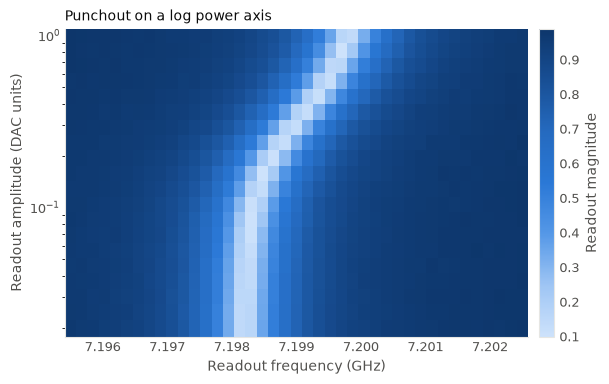

In [21]:
power_scan = qp.QProgram(label="punchout_log", schema=schema)
log_amp = power_scan.variable("ro_amp", label="Readout amplitude", units="DAC units")
log_freq = power_scan.variable("ro_freq", label="Readout frequency", units="Hz")

with power_scan.average(shots=50):
    with power_scan.sweep(log_amp, qp.Logspace(0.02, 1.0, 20)):
        with power_scan.sweep(log_freq, qp.Linspace(7.1955e9, 7.2025e9, 41)):
            power_scan.set_gain(q[0].readout, log_amp)
            power_scan.set_frequency(q[0].readout, log_freq)
            m_log = power_scan.measure(q[0].readout, "readout", "weights")

log_result = qp.simulate(
    power_scan, model=qp.MockMeasurementModel(response=s21_power, noise=0.02, seed=13)
)
log_iq = log_result.get(m_log)
log_amps = log_iq.coords["ro_amp"].values
log_freqs = log_iq.coords["ro_freq"].values
log_mag = np.abs(log_iq.sel(IQ="I") + 1j * log_iq.sel(IQ="Q")).values
log_dip = log_freqs[log_mag.argmin(axis=1)]

print("Logspace kind:", qp.Logspace(0.02, 1.0, 20).KIND, "against Linspace:",
      qp.Linspace(0.02, 1.0, 20).KIND)
print(f"{log_amps[0]:.3f} V -> {log_dip[0] / 1e9:.6f} GHz, "
      f"target f_r + chi = {(DEVICE['q0_fr'] + DEVICE['q0_chi']) / 1e9:.6f}")
print(f"{log_amps[-1]:.3f} V -> {log_dip[-1] / 1e9:.6f} GHz, "
      f"target bare f_r = {DEVICE['q0_fr'] / 1e9:.6f}")

ax_log = log_result.plot(
    m_log,
    coords={"ro_freq": Quantity(units="GHz", transform=lambda v: v / 1e9)},
    value=Quantity("Readout magnitude"),
    title="Punchout on a log power axis",
)
ax_log.set_yscale("log")

### Parallel loops

Either map cost you a rectangle of measurements and most of them were off resonance. Now that you know where the ridge is, you can walk along it instead, stepping the amplitude and the frequency **together**, one point per amplitude.

`sweep(a, src) | sweep(b, src)` is that lockstep pair. Both loops advance on the same tick, so they must have the same length. Every source can report its length without running, so mismatched lengths raise `ValidationError` on the `|` line itself, not at run time. In the result the pair shares one dimension named `"ro_amp|ro_freq"`, carrying both coordinate arrays. Point $k$ of one is always paired with point $k$ of the other, and there is no grid.

The frequency list here comes from the linear map, so it is a `Values` source, arbitrary by construction.

### Drawing a shared dimension

One dimension carrying two coordinates is more than an axis can hold, and `plot` draws both rather than dropping one. The first variable of the pair goes along the bottom and the second on a twin scale across the top, in the order the loops were written. Those top ticks land on samples instead of round numbers, because tick $k$ and sample $k$ are the same measurement.

The twin takes a `coords=` restatement keyed by its own name, so the frequencies below are drawn as a detuning from the bare resonator in MHz. Left in gigahertz they would have been five ticks that all round to 7.199.

Reach for a diagonal whenever the interesting region is a curve rather than a rectangle. Ridge tracking like this. Chevron cuts, where the gate duration and the flux amplitude have to move together. Any scan where one parameter has to be compensated as another moves. The reason people still take the full map first is that you cannot walk a ridge you have not found.

dims:   ('ro_amp|ro_freq', 'IQ') (25, 2)
coords: ['ro_amp', 'ro_freq', 'IQ']
measurements: 25 against 1025 for the full map
|S21| along the ridge: [0.144 0.12  0.113 0.107 0.128 0.142] ...
still in the dip everywhere: True


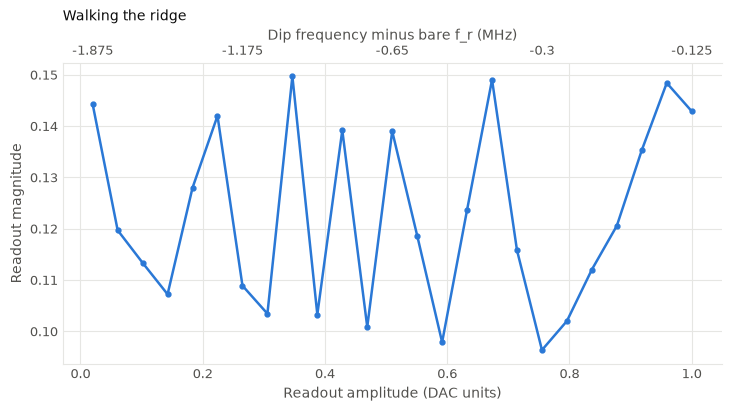

In [22]:
ridge = qp.QProgram(label="punchout_ridge", schema=schema)
d_amp = ridge.variable("ro_amp", label="Readout amplitude", units="DAC units")
d_freq = ridge.variable("ro_freq", label="Readout frequency", units="Hz")

with ridge.average(shots=50):
    with ridge.sweep(d_amp, qp.Values(amps)) | ridge.sweep(d_freq, qp.Values(dip_per_amp)):
        ridge.set_gain(q[0].readout, d_amp)
        ridge.set_frequency(q[0].readout, d_freq)
        m_ridge = ridge.measure(q[0].readout, "readout", "weights")

ridge_result = qp.simulate(
    ridge, model=qp.MockMeasurementModel(response=s21_power, noise=0.02, seed=11)
)
ridge_iq = ridge_result.get(m_ridge)
ridge_mag = np.abs(ridge_iq.sel(IQ="I") + 1j * ridge_iq.sel(IQ="Q")).values

print("dims:  ", ridge_iq.dims, ridge_iq.shape)
print("coords:", list(ridge_iq.coords))
print("measurements:", ridge_iq.sizes["ro_amp|ro_freq"], "against", 25 * 41, "for the full map")
print("|S21| along the ridge:", np.round(ridge_mag[:6], 3), "...")
print("still in the dip everywhere:", bool(ridge_mag.max() < 0.3))

ax_ridge = ridge_result.plot(
    m_ridge,
    channels="magnitude",
    coords={
        "ro_freq": Quantity(
            "Dip frequency minus bare f_r", "MHz", lambda v: (v - DEVICE["q0_fr"]) / 1e6
        )
    },
    value=Quantity("Readout magnitude"),
    style=Style(markers=True),
    title="Walking the ridge",
)

### 🧩 Exercise 2.1

Scan both readout resonators in one lockstep pass. Qubit 1 has its own readout resonator at 7.35 GHz, and its band does not overlap qubit 0's, so scanning them one after the other doubles your measurement time for no reason. A 50-qubit chip spreads 50 resonators across a couple of gigahertz, and frequency multiplexing is why.

1. Declare `f0` and `f1` and sweep them in parallel with `sweep(f0, ...) | sweep(f1, ...)`. Give each a 41-point `Linspace` over its own 10 MHz band (`7.195` to `7.205` GHz, and `7.345` to `7.355` GHz). Use `shots=100`.
2. Inside the loop, `set_frequency` on each readout bus and `measure` both. You get two handles.
3. Write one response function for both resonators. It receives `bus`, so it can pick which frequency and which centre to use. `q1_fr` is in `DEVICE`, and no linewidth for qubit 1 is, so let `q0_kappa` stand in for both.
4. Print the dims of each record and the dip frequency each one found, then write a comment explaining why there is one dimension of length 41 here and not a 41 x 41 grid.
5. Draw each record with `result.plot(handle, channels="magnitude")`. Both records live on the same `"f0|f1"` dimension, so the default reads `f0` below and `f1` above. The q0 record wants that order and the q1 record wants `x="f1"`. Restate the drawn axes into GHz with `coords=`, and note that a `coords=` key naming an axis the figure does not draw raises.

In [ ]:
# TODO: scan both readout resonators in one lockstep sweep.
# 1) f0 over 7.195 to 7.205 GHz, f1 over 7.345 to 7.355 GHz, 41 points each, shots=100.
# 2) with pair.sweep(f0, ...) | pair.sweep(f1, ...):  then set_frequency and measure on both buses.
# 3) One response(bus, env): compare bus to q[0].readout to choose the centre and the env key.
#    DEVICE["q1_fr"] is 7.35e9.
# 4) Print each record's dims and its dip frequency, and explain the single 41-long dimension
#    in a comment.
# 5) result.plot(m_q0, channels="magnitude") reads f0 below and f1 above; the q1 record wants
#    x="f1". Restate the drawn axes into GHz with coords={...: Quantity(units="GHz",
#    transform=lambda v: v / 1e9)}.

## Recap

- A **variable** is a hole in the program, and the loop that binds it decides what goes in. Expressions built on it re-evaluate every iteration, waveform parameters included. Its `label` and `units` follow the data out and label the axes of every figure.
- A **sweep source** says how the variable moves. `Range` and `Linspace` are `linear`, so a sequencer can run them from a register. `Values`, `Logspace`, `File` and the combinators are `arbitrary`, and a platform pays for that in table space or host round trips. `Range` includes its stop value only when the step divides the span, and `Values` stays arbitrary even when its numbers are evenly spaced.
- **`average(shots)` adds no dimension.** It shrinks the noise on `iq` as $1/\sqrt{N}$ and turns `state` from a 0/1 outcome into a population. Amplifier noise and projection noise both obey that law, and only one of them can be fixed by buying something.
- The **measurement model** is the only thing in the loop that produces a number. No timing, no pulse physics. The program and the analysis are the real parts.
- Results are **xarray**, one dimension per enclosing sweep, outermost first, named after your variable ids, with one shared `"a|b"` dimension for a parallel pair. `result.plot` picks a line for one swept dimension and a heatmap for two, and returns the `Axes` your fits and reference lines go on.

## Next

You now have the bare resonator, its linewidth, the loss budget hiding in the dip depth, and a punchout map that says how many photons you can spend before the qubit stops showing through. Part 3 puts a second tone on the drive line and goes looking for the qubit itself.